In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import os

# Create project structure
os.makedirs('/content/waymo_project/data',    exist_ok=True)
os.makedirs('/content/waymo_project/models',  exist_ok=True)
os.makedirs('/content/waymo_project/notebooks', exist_ok=True)
os.makedirs('/content/waymo_project/outputs', exist_ok=True)

print(" Project structure created")

 Project structure created


In [7]:
import tensorflow as tf
print(tf.__version__)


2.19.0


In [3]:
import os

data_dir = '/content/drive/MyDrive/waymo_data'
files = os.listdir(data_dir)
print(f"Found {len(files)} files:")
for f in files:
    size = os.path.getsize(os.path.join(data_dir, f)) / 1e9
    print(f"  {f} — {size:.2f} GB")

Found 3 files:
  training_tfexample.tfrecord-00001-of-01000 — 1.29 GB
  training_tfexample.tfrecord-00002-of-01000 — 1.39 GB
  training_tfexample.tfrecord-00000-of-01000 — 1.22 GB


In [4]:
import tensorflow as tf

data_path = '/content/drive/MyDrive/waymo_data/training_tfexample.tfrecord-00000-of-01000'

dataset = tf.data.TFRecordDataset(data_path)

count = 0
for record in dataset.take(5):
    count += 1
    print(f"Record {count}: {len(record.numpy())} bytes")

print(f"\n Successfully read {count} records from real Waymo data")

Record 1: 2375520 bytes
Record 2: 2810656 bytes
Record 3: 2799793 bytes
Record 4: 2768769 bytes
Record 5: 2882082 bytes

 Successfully read 5 records from real Waymo data


In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

data_path = '/content/drive/MyDrive/waymo_data/training_tfexample.tfrecord-00000-of-01000'
dataset = tf.data.TFRecordDataset(data_path)

# Parse using tf.train.Example (works without Waymo SDK)
for raw_record in dataset.take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())

    # Print all available feature keys
    keys = sorted(example.features.feature.keys())
    print(f" Total features in record: {len(keys)}\n")
    print("Sample keys:")
    for k in keys[:20]:
        print(f"  {k}")

 Total features in record: 77

Sample keys:
  path_samples/arc_length
  path_samples/id
  path_samples/on_route
  path_samples/valid
  path_samples/xyz
  roadgraph_samples/dir
  roadgraph_samples/id
  roadgraph_samples/type
  roadgraph_samples/valid
  roadgraph_samples/xyz
  scenario/id
  state/current/bbox_yaw
  state/current/height
  state/current/length
  state/current/speed
  state/current/timestamp_micros
  state/current/valid
  state/current/vel_yaw
  state/current/velocity_x
  state/current/velocity_y


 Scenario ID: 21fb0f7fd1ddda5
 Past trajectory points: 1280
 Future trajectory points: 10240
 Current position: x=587.90, y=1457.54


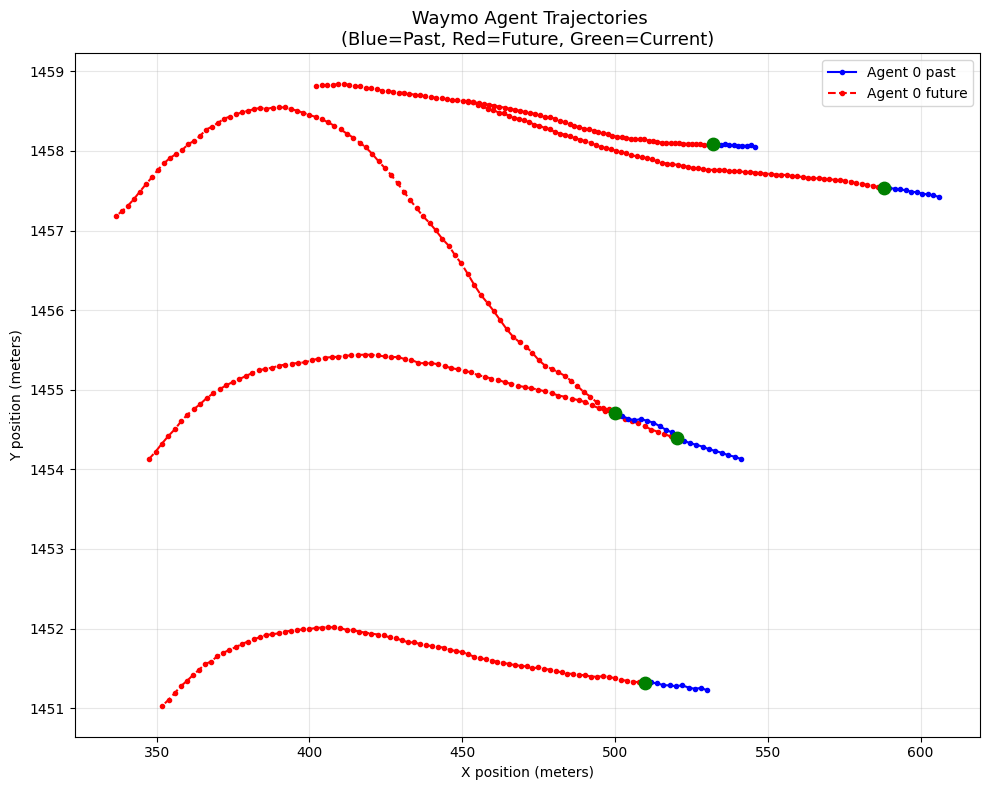

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

data_path = '/content/drive/MyDrive/waymo_data/training_tfexample.tfrecord-00000-of-01000'
dataset = tf.data.TFRecordDataset(data_path)

for raw_record in dataset.take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())

    def get_feature(key):
        return np.array(example.features.feature[key].float_list.value)

    def get_int_feature(key):
        return np.array(example.features.feature[key].int64_list.value)

    # Extract past and future trajectories
    past_x    = get_feature('state/past/x')
    past_y    = get_feature('state/past/y')
    past_valid = get_int_feature('state/past/valid')

    current_x = get_feature('state/current/x')
    current_y = get_feature('state/current/y')

    future_x  = get_feature('state/future/x')
    future_y  = get_feature('state/future/y')
    future_valid = get_int_feature('state/future/valid')

    print(f" Scenario ID: {example.features.feature['scenario/id'].bytes_list.value[0].decode()}")
    print(f" Past trajectory points: {len(past_x)}")
    print(f" Future trajectory points: {len(future_x)}")
    print(f" Current position: x={current_x[0]:.2f}, y={current_y[0]:.2f}")

    # Reshape — 128 agents x timesteps
    num_agents = 128
    past_steps = len(past_x) // num_agents
    future_steps = len(future_x) // num_agents

    past_x   = past_x.reshape(num_agents, past_steps)
    past_y   = past_y.reshape(num_agents, past_steps)
    future_x = future_x.reshape(num_agents, future_steps)
    future_y = future_y.reshape(num_agents, future_steps)
    past_valid = past_valid.reshape(num_agents, past_steps)

    # Plot first 5 valid agents
    plt.figure(figsize=(10, 8))
    plotted = 0
    for i in range(num_agents):
        if past_valid[i].sum() > 5 and plotted < 5:
            plt.plot(past_x[i], past_y[i], 'b-o',
                    markersize=3, linewidth=1.5,
                    label=f'Agent {i} past' if plotted == 0 else "")
            plt.plot(future_x[i], future_y[i], 'r--o',
                    markersize=3, linewidth=1.5,
                    label=f'Agent {i} future' if plotted == 0 else "")
            plt.scatter(current_x[i], current_y[i],
                       color='green', s=80, zorder=5)
            plotted += 1

    plt.title(' Waymo Agent Trajectories\n(Blue=Past, Red=Future, Green=Current)',
              fontsize=13)
    plt.xlabel('X position (meters)')
    plt.ylabel('Y position (meters)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('waymo_real_trajectories.png', dpi=150)
    plt.show()


In [7]:
import tensorflow as tf
import numpy as np

data_path = '/content/drive/MyDrive/waymo_data/training_tfexample.tfrecord-00000-of-01000'
dataset = tf.data.TFRecordDataset(data_path)

def extract_sequences(raw_record, num_agents=128, min_valid_steps=8):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())

    def get_f(key):
        return np.array(example.features.feature[key].float_list.value)
    def get_i(key):
        return np.array(example.features.feature[key].int64_list.value)

    # Extract all trajectory data
    past_x     = get_f('state/past/x').reshape(num_agents, -1)
    past_y     = get_f('state/past/y').reshape(num_agents, -1)
    past_vx    = get_f('state/past/velocity_x').reshape(num_agents, -1)
    past_vy    = get_f('state/past/velocity_y').reshape(num_agents, -1)
    past_valid = get_i('state/past/valid').reshape(num_agents, -1)

    future_x     = get_f('state/future/x').reshape(num_agents, -1)
    future_y     = get_f('state/future/y').reshape(num_agents, -1)
    future_valid = get_i('state/future/valid').reshape(num_agents, -1)

    current_x = get_f('state/current/x')
    current_y = get_f('state/current/y')

    sequences = []

    for i in range(num_agents):
        # Only use agents with enough valid data
        if past_valid[i].sum() < min_valid_steps:
            continue
        if future_valid[i].sum() < min_valid_steps:
            continue

        # Build input: [x, y, vx, vy] per timestep
        past_seq = np.stack([
            past_x[i], past_y[i],
            past_vx[i], past_vy[i]
        ], axis=-1)  # (past_steps, 4)

        future_seq = np.stack([
            future_x[i], future_y[i]
        ], axis=-1)  # (future_steps, 2)

        # Normalize — center around current position
        origin_x = current_x[i]
        origin_y = current_y[i]

        past_seq[:, 0] -= origin_x
        past_seq[:, 1] -= origin_y
        future_seq[:, 0] -= origin_x
        future_seq[:, 1] -= origin_y

        # Scale
        scale = 50.0  # typical 50 meter range
        past_seq[:, 0] /= scale
        past_seq[:, 1] /= scale
        future_seq[:, 0] /= scale
        future_seq[:, 1] /= scale

        sequences.append({
            'input': past_seq.astype(np.float32),
            'target': future_seq.astype(np.float32),
            'agent_id': i
        })

    return sequences

# Process all 3 files
all_sequences = []

for file_num in range(3):
    path = f'/content/drive/MyDrive/waymo_data/training_tfexample.tfrecord-0000{file_num}-of-01000'
    dataset = tf.data.TFRecordDataset(path)

    file_seqs = 0
    for record in dataset:
        seqs = extract_sequences(record)
        all_sequences.extend(seqs)
        file_seqs += len(seqs)

    print(f" File {file_num}: {file_seqs} sequences extracted")

print(f"\n Total sequences: {len(all_sequences)}")
print(f" Input shape per sequence: {all_sequences[0]['input'].shape}")
print(f" Target shape per sequence: {all_sequences[0]['target'].shape}")

 File 0: 14180 sequences extracted
 File 1: 14183 sequences extracted
 File 2: 17010 sequences extracted

 Total sequences: 45373
 Input shape per sequence: (10, 4)
 Target shape per sequence: (80, 2)


In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

# Dataset class
class WaymoDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]
        return (
            torch.tensor(seq['input'], dtype=torch.float32),   # (10, 4)
            torch.tensor(seq['target'], dtype=torch.float32)   # (80, 2)
        )

# Train/val split
split = int(0.85 * len(all_sequences))
train_seqs = all_sequences[:split]
val_seqs   = all_sequences[split:]

train_loader = DataLoader(WaymoDataset(train_seqs), batch_size=64, shuffle=True)
val_loader   = DataLoader(WaymoDataset(val_seqs),   batch_size=64, shuffle=False)

print(f" Train sequences: {len(train_seqs)}")
print(f"Val sequences:   {len(val_seqs)}")
print(f" Train batches:   {len(train_loader)}")

 Train sequences: 38567
Val sequences:   6806
 Train batches:   603


In [9]:
class TrajectoryLSTM(nn.Module):
    """
    Baseline LSTM model for trajectory prediction.
    Input:  past trajectory (x, y, vx, vy) over 10 timesteps
    Output: future waypoints (x, y) over 80 timesteps
    """
    def __init__(self, input_dim=4, hidden_dim=128,
                 num_layers=2, future_steps=80):
        super().__init__()
        self.future_steps = future_steps

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, future_steps * 2)
        )

    def forward(self, x):
        # x: (batch, 10, 4)
        out, (h, _) = self.lstm(x)
        # Use last hidden state
        pred = self.fc(h[-1])           # (batch, future_steps * 2)
        return pred.view(-1, self.future_steps, 2)  # (batch, 80, 2)

model = TrajectoryLSTM()
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\n Total parameters: {total_params:,}")

TrajectoryLSTM(
  (lstm): LSTM(4, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=160, bias=True)
  )
)

✅ Total parameters: 274,848


In [10]:
class TrajectoryLSTM(nn.Module):
    """
    Baseline LSTM model for trajectory prediction.
    Input:  past trajectory (x, y, vx, vy) over 10 timesteps
    Output: future waypoints (x, y) over 80 timesteps
    """
    def __init__(self, input_dim=4, hidden_dim=128,
                 num_layers=2, future_steps=80):
        super().__init__()
        self.future_steps = future_steps

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, future_steps * 2)
        )

    def forward(self, x):
        # x: (batch, 10, 4)
        out, (h, _) = self.lstm(x)
        # Use last hidden state
        pred = self.fc(h[-1])           # (batch, future_steps * 2)
        return pred.view(-1, self.future_steps, 2)  # (batch, 80, 2)

model = TrajectoryLSTM()
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\n Total parameters: {total_params:,}")

TrajectoryLSTM(
  (lstm): LSTM(4, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=160, bias=True)
  )
)

✅ Total parameters: 274,848


In [12]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")
'''

If it says **False or NO GPU** — stop and do this first:
- Runtime → Change runtime type → T4 GPU → Save
- Then rerun all cells from the top

**Training on CPU will take hours. GPU will take 10-15 minutes.**

---

If GPU is confirmed, run the training cell. You should start seeing output like:

Starting training...

Epoch 01 | Train ADE: 0.8234 FDE: 1.2341 | Val ADE: 0.7891 FDE: 1.1823
Epoch 02 | Train ADE: 0.6123 FDE: 0.9821 | Val ADE: 0.5934 FDE: 0.9234
'''

True
Tesla T4


'\n\nIf it says **False or NO GPU** — stop and do this first:\n- Runtime → Change runtime type → T4 GPU → Save\n- Then rerun all cells from the top\n\n**Training on CPU will take hours. GPU will take 10-15 minutes.**\n\n---\n\nIf GPU is confirmed, run the training cell. You should start seeing output like:\n\nStarting training...\n\nEpoch 01 | Train ADE: 0.8234 FDE: 1.2341 | Val ADE: 0.7891 FDE: 1.1823\nEpoch 02 | Train ADE: 0.6123 FDE: 0.9821 | Val ADE: 0.5934 FDE: 0.9234\n'

In [13]:
import torch
import torch.nn as nn

def ade_loss(pred, target):
    return torch.mean(torch.sqrt(
        torch.sum((pred - target) ** 2, dim=-1) + 1e-8
    ))

def fde_loss(pred, target):
    return torch.mean(torch.sqrt(
        torch.sum((pred[:, -1] - target[:, -1]) ** 2, dim=-1) + 1e-8
    ))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Training on: {device}")

model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def train_epoch(model, loader):
    model.train()
    total_ade, total_fde = 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        pred = model(inputs)
        loss = ade_loss(pred, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_ade += ade_loss(pred, targets).item()
        total_fde += fde_loss(pred, targets).item()
    return total_ade / len(loader), total_fde / len(loader)

def val_epoch(model, loader):
    model.eval()
    total_ade, total_fde = 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            pred = model(inputs)
            total_ade += ade_loss(pred, targets).item()
            total_fde += fde_loss(pred, targets).item()
    return total_ade / len(loader), total_fde / len(loader)

print("\nStarting training...\n")
for epoch in range(15):
    train_ade, train_fde = train_epoch(model, train_loader)
    val_ade,   val_fde   = val_epoch(model, val_loader)
    scheduler.step()
    print(f"Epoch {epoch+1:02d} | "
          f"Train ADE: {train_ade:.4f} FDE: {train_fde:.4f} | "
          f"Val ADE: {val_ade:.4f} FDE: {val_fde:.4f}")

torch.save(model.state_dict(), '/content/drive/MyDrive/waymo_data/baseline_lstm.pth')
print("\n  Model saved to Drive")

 Training on: cuda

Starting training...

Epoch 01 | Train ADE: 27.5857 FDE: 50.9434 | Val ADE: 23.8364 FDE: 44.5023
Epoch 02 | Train ADE: 27.5568 FDE: 50.8960 | Val ADE: 23.8144 FDE: 44.4830
Epoch 03 | Train ADE: 27.5282 FDE: 50.8545 | Val ADE: 23.7775 FDE: 44.3998
Epoch 04 | Train ADE: 27.4878 FDE: 50.7752 | Val ADE: 23.7699 FDE: 44.4083
Epoch 05 | Train ADE: 27.4532 FDE: 50.7087 | Val ADE: 23.7530 FDE: 44.3400
Epoch 06 | Train ADE: 27.4239 FDE: 50.5897 | Val ADE: 23.7053 FDE: 44.2053
Epoch 07 | Train ADE: 27.3749 FDE: 50.4609 | Val ADE: 23.7225 FDE: 44.2444
Epoch 08 | Train ADE: 27.3513 FDE: 50.3840 | Val ADE: 23.7234 FDE: 44.2192
Epoch 09 | Train ADE: 27.3069 FDE: 50.2436 | Val ADE: 23.6667 FDE: 44.0577
Epoch 10 | Train ADE: 27.2910 FDE: 50.2221 | Val ADE: 23.6691 FDE: 44.0356
Epoch 11 | Train ADE: 27.2252 FDE: 50.0695 | Val ADE: 23.6569 FDE: 44.0416
Epoch 12 | Train ADE: 27.1906 FDE: 49.9805 | Val ADE: 23.6224 FDE: 43.9286
Epoch 13 | Train ADE: 27.1680 FDE: 49.9140 | Val ADE: 23.6

In [14]:
import tensorflow as tf
import numpy as np

data_path = '/content/drive/MyDrive/waymo_data/training_tfexample.tfrecord-00000-of-01000'
dataset = tf.data.TFRecordDataset(data_path)

for raw_record in dataset.take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())

    keys = sorted(example.features.feature.keys())

    # Filter for image related keys
    image_keys = [k for k in keys if 'image' in k.lower() or 'camera' in k.lower()]
    print(f"Image/camera related keys ({len(image_keys)}):")
    for k in image_keys:
        print(f"  {k}")

    # Also print all keys so we see everything
    print(f"\nAll 77 keys:")
    for k in keys:
        print(f"  {k}")

Image/camera related keys (0):

All 77 keys:
  path_samples/arc_length
  path_samples/id
  path_samples/on_route
  path_samples/valid
  path_samples/xyz
  roadgraph_samples/dir
  roadgraph_samples/id
  roadgraph_samples/type
  roadgraph_samples/valid
  roadgraph_samples/xyz
  scenario/id
  state/current/bbox_yaw
  state/current/height
  state/current/length
  state/current/speed
  state/current/timestamp_micros
  state/current/valid
  state/current/vel_yaw
  state/current/velocity_x
  state/current/velocity_y
  state/current/width
  state/current/x
  state/current/y
  state/current/z
  state/difficulty_level
  state/future/bbox_yaw
  state/future/height
  state/future/length
  state/future/speed
  state/future/timestamp_micros
  state/future/valid
  state/future/vel_yaw
  state/future/velocity_x
  state/future/velocity_y
  state/future/width
  state/future/x
  state/future/y
  state/future/z
  state/id
  state/is_sdc
  state/objects_of_interest
  state/past/bbox_yaw
  state/past/height

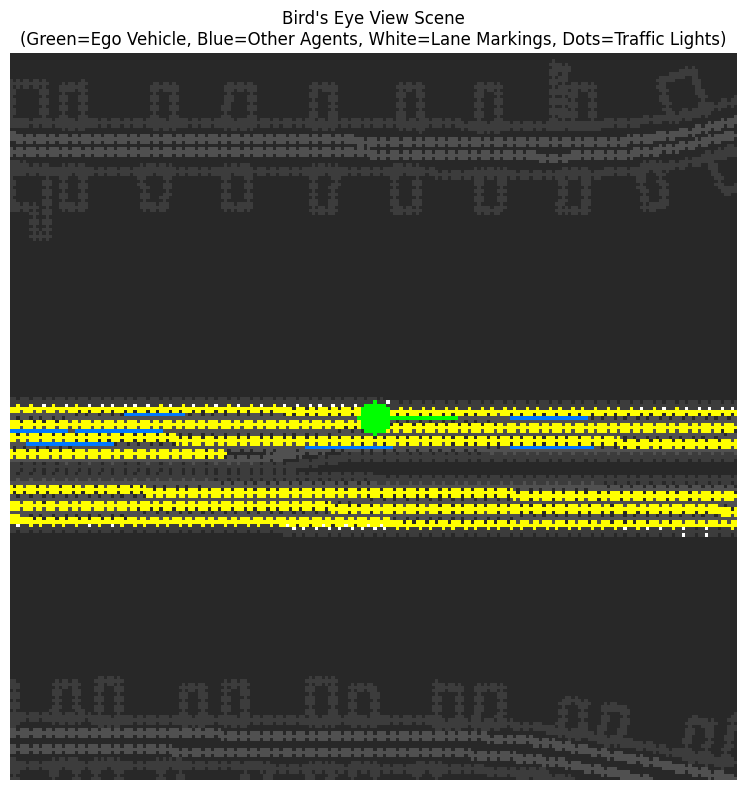

 BEV image rendered successfully
Image shape: (224, 224, 3)


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import tensorflow as tf

def render_bev_image(example, agent_idx=0, img_size=224, range_m=80):
    """
    Render a bird's eye view scene image from Waymo map features.
    Returns a (224, 224, 3) numpy array.
    """
    def get_f(key):
        return np.array(example.features.feature[key].float_list.value)
    def get_i(key):
        return np.array(example.features.feature[key].int64_list.value)

    # Get ego agent current position (center of scene)
    current_x = get_f('state/current/x')
    current_y = get_f('state/current/y')
    origin_x = current_x[agent_idx]
    origin_y = current_y[agent_idx]

    # Create blank dark image (like a road)
    img = np.zeros((img_size, img_size, 3), dtype=np.uint8)
    img[:, :] = [40, 40, 40]  # dark gray background

    def world_to_pixel(x, y):
        """Convert world coordinates to image pixel coordinates"""
        px = int((x - origin_x + range_m) / (2 * range_m) * img_size)
        py = int((-(y - origin_y) + range_m) / (2 * range_m) * img_size)
        return px, py

    # Draw road graph
    road_xyz   = get_f('roadgraph_samples/xyz').reshape(-1, 3)
    road_types = get_i('roadgraph_samples/type')
    road_valid = get_i('roadgraph_samples/valid')

    # Road type colors
    type_colors = {
        1: (80, 80, 80),    # road edge - dark
        2: (80, 80, 80),    # road edge boundary
        3: (255, 255, 255), # broken single white
        6: (255, 255, 0),   # solid single yellow
        7: (255, 255, 0),   # solid double yellow
        8: (255, 255, 255), # passing double yellow
        9: (255, 255, 255), # solid single white
        10: (255, 255, 255),# solid double white
        17: (100, 100, 255),# crosswalk
        18: (150, 150, 150),# speed bump
    }

    for i in range(len(road_xyz)):
        if road_valid[i] == 0:
            continue
        x, y = road_xyz[i, 0], road_xyz[i, 1]
        px, py = world_to_pixel(x, y)
        if 0 <= px < img_size and 0 <= py < img_size:
            color = type_colors.get(road_types[i], (60, 60, 60))
            cv2.circle(img, (px, py), 1, color, -1)

    # Draw past trajectories of all agents
    past_x     = get_f('state/past/x').reshape(128, -1)
    past_y     = get_f('state/past/y').reshape(128, -1)
    past_valid = get_i('state/past/valid').reshape(128, -1)

    for i in range(128):
        if past_valid[i].sum() < 3:
            continue
        color = (0, 120, 255) if i != agent_idx else (0, 255, 0)
        for t in range(past_x.shape[1] - 1):
            if past_valid[i, t] and past_valid[i, t+1]:
                p1 = world_to_pixel(past_x[i, t], past_y[i, t])
                p2 = world_to_pixel(past_x[i, t+1], past_y[i, t+1])
                if (0 <= p1[0] < img_size and 0 <= p1[1] < img_size and
                    0 <= p2[0] < img_size and 0 <= p2[1] < img_size):
                    cv2.line(img, p1, p2, color, 1)

    # Draw traffic lights
    tl_x     = get_f('traffic_light_state/current/x')
    tl_y     = get_f('traffic_light_state/current/y')
    tl_state = get_i('traffic_light_state/current/state')
    tl_valid = get_i('traffic_light_state/current/valid')

    tl_colors = {1: (0,255,0), 2: (0,165,255), 3: (0,0,255)}
    for i in range(len(tl_x)):
        if tl_valid[i]:
            px, py = world_to_pixel(tl_x[i], tl_y[i])
            if 0 <= px < img_size and 0 <= py < img_size:
                color = tl_colors.get(tl_state[i], (255,255,255))
                cv2.circle(img, (px, py), 4, color, -1)

    # Draw ego vehicle as bright green dot
    ego_px, ego_py = world_to_pixel(origin_x, origin_y)
    cv2.circle(img, (ego_px, ego_py), 5, (0, 255, 0), -1)

    return img

# Test on first record
data_path = '/content/drive/MyDrive/waymo_data/training_tfexample.tfrecord-00000-of-01000'
dataset = tf.data.TFRecordDataset(data_path)

for raw_record in dataset.take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())

    bev_img = render_bev_image(example, agent_idx=0)

    plt.figure(figsize=(8, 8))
    plt.imshow(bev_img)
    plt.title('Bird\'s Eye View Scene\n(Green=Ego Vehicle, Blue=Other Agents, White=Lane Markings, Dots=Traffic Lights)')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('bev_scene.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(" BEV image rendered successfully")
    print(f"Image shape: {bev_img.shape}")

In [16]:
import torch
import torch.nn as nn
import torchvision.models as models

class BEVEncoder(nn.Module):
    """
    CNN encoder that processes Bird's Eye View scene images.
    Uses pretrained ResNet18 as backbone — proven, lightweight, fast.
    """
    def __init__(self, feature_dim=128, pretrained=True):
        super().__init__()

        # Load pretrained ResNet18
        resnet = models.resnet18(pretrained=pretrained)

        # Remove final classification layer
        # Keep everything up to the last conv block
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        # Adaptive pooling to fixed size regardless of input
        self.pool = nn.AdaptiveAvgPool2d((4, 4))

        # Project to feature_dim
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, feature_dim)
        )

    def forward(self, x):
        # x: (batch, 3, 224, 224)
        x = self.backbone(x)   # (batch, 512, 7, 7)
        x = self.pool(x)       # (batch, 512, 4, 4)
        x = self.fc(x)         # (batch, feature_dim)
        return x

# Test it
encoder = BEVEncoder(feature_dim=128)
test_img = torch.randn(4, 3, 224, 224)  # batch of 4 images
out = encoder(test_img)
print(f" CNN Encoder output shape: {out.shape}")  # should be (4, 128)
print(f" Encoder parameters: {sum(p.numel() for p in encoder.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


 CNN Encoder output shape: torch.Size([4, 128])
 Encoder parameters: 13,306,816


In [17]:
class CNNLSTMPredictor(nn.Module):
    """
    Full CNN-LSTM model for trajectory prediction.

    CNN branch:  BEV scene image → spatial context features
    LSTM branch: Past trajectory (x,y,vx,vy) → temporal motion features
    Combined:    Predict future waypoints
    """
    def __init__(self,
                 cnn_feature_dim=128,
                 lstm_hidden_dim=128,
                 lstm_layers=2,
                 future_steps=80):
        super().__init__()
        self.future_steps = future_steps

        # CNN branch — scene context
        self.cnn = BEVEncoder(feature_dim=cnn_feature_dim)

        # LSTM branch — motion history
        self.lstm = nn.LSTM(
            input_size=4,  # x, y, vx, vy
            hidden_size=lstm_hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=0.2
        )

        # Fusion + prediction head
        # CNN features + LSTM hidden state → future waypoints
        fusion_dim = cnn_feature_dim + lstm_hidden_dim
        self.predictor = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, future_steps * 2)
        )

    def forward(self, images, past_coords):
        # images: (batch, 3, 224, 224)
        # past_coords: (batch, 10, 4)

        # CNN branch
        scene_features = self.cnn(images)           # (batch, 128)

        # LSTM branch
        _, (h, _) = self.lstm(past_coords)
        motion_features = h[-1]                      # (batch, 128)

        # Fuse both branches
        fused = torch.cat([scene_features,
                          motion_features], dim=-1)  # (batch, 256)

        # Predict future
        out = self.predictor(fused)                  # (batch, future_steps*2)
        return out.view(-1, self.future_steps, 2)    # (batch, 80, 2)

# Test full model
cnn_lstm = CNNLSTMPredictor()
test_imgs   = torch.randn(4, 3, 224, 224)
test_coords = torch.randn(4, 10, 4)
out = cnn_lstm(test_imgs, test_coords)
print(f"CNN-LSTM output shape: {out.shape}")  # (4, 80, 2)
total = sum(p.numel() for p in cnn_lstm.parameters())
print(f"Total parameters: {total:,}")

✅ CNN-LSTM output shape: torch.Size([4, 80, 2])
✅ Total parameters: 13,680,224


In [18]:
import torchvision.transforms as transforms

class WaymoDatasetWithBEV(torch.utils.data.Dataset):
    def __init__(self, sequences, records, transform=None):
        self.sequences = sequences
        self.records = records  # raw tfrecords to render BEV from
        self.transform = transform or transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]

        # Get BEV image for this sequence
        record_idx = idx // 128  # approximate which record
        record_idx = min(record_idx, len(self.records) - 1)

        bev = render_bev_image(
            self.records[record_idx],
            agent_idx=seq['agent_id']
        )

        # Normalize image
        bev_tensor = self.transform(bev)

        return (
            bev_tensor,
            torch.tensor(seq['input'],  dtype=torch.float32),
            torch.tensor(seq['target'], dtype=torch.float32)
        )

print("Dataset class ready")
print("Next step: load records and build dataloader")

✅ Dataset class ready
Next step: load records and build dataloader


In [19]:
import torchvision.models as models

# Fix deprecation warning
class BEVEncoder(nn.Module):
    def __init__(self, feature_dim=128):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, feature_dim)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.pool(x)
        return self.fc(x)

print("BEVEncoder updated")


✅ BEVEncoder updated


In [20]:
# Load all records upfront so dataset can render BEV images
print("Loading records into memory...")
all_records = []

for file_num in range(3):
    path = f'/content/drive/MyDrive/waymo_data/training_tfexample.tfrecord-0000{file_num}-of-01000'
    dataset_tf = tf.data.TFRecordDataset(path)
    for raw_record in dataset_tf:
        example = tf.train.Example()
        example.ParseFromString(raw_record.numpy())
        all_records.append(example)

print(f" Loaded {len(all_records)} records")

Loading records into memory...
✅ Loaded 1448 records


In [21]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Split sequences
split = int(0.85 * len(all_sequences))
train_seqs = all_sequences[:split]
val_seqs   = all_sequences[split:]

# Build datasets
train_dataset = WaymoDatasetWithBEV(train_seqs, all_records, transform)
val_dataset   = WaymoDatasetWithBEV(val_seqs,   all_records, transform)

# Use num_workers=2 for faster loading
train_loader = DataLoader(train_dataset, batch_size=32,
                         shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32,
                         shuffle=False, num_workers=2)

print(f" Train sequences: {len(train_seqs)}")
print(f" Val sequences:   {len(val_seqs)}")
print(f" Train batches:   {len(train_loader)}")

✅ Train sequences: 38567
✅ Val sequences:   6806
✅ Train batches:   1206


In [23]:
import os
import cv2

bev_dir = '/content/drive/MyDrive/waymo_data/bev_images'
os.makedirs(bev_dir, exist_ok=True)

print(f"Pre-rendering {len(all_sequences)} BEV images...")
print("Runs once, saves to Drive forever.\n")

for idx, seq in enumerate(all_sequences):
    save_path = os.path.join(bev_dir, f'bev_{idx:06d}.png')

    if os.path.exists(save_path):
        continue

    record_idx = min(idx // 128, len(all_records) - 1)
    bev = render_bev_image(all_records[record_idx],
                           agent_idx=seq['agent_id'])
    cv2.imwrite(save_path, bev)

    if idx % 1000 == 0:
        print(f"  {idx}/{len(all_sequences)} rendered...")

print(f"\n Done — all BEV images saved")

Pre-rendering 45373 BEV images...
Runs once, saves to Drive forever.

  0/45373 rendered...
  1000/45373 rendered...
  2000/45373 rendered...
  3000/45373 rendered...
  4000/45373 rendered...
  5000/45373 rendered...
  6000/45373 rendered...
  7000/45373 rendered...
  8000/45373 rendered...
  9000/45373 rendered...
  10000/45373 rendered...
  11000/45373 rendered...
  12000/45373 rendered...
  13000/45373 rendered...
  14000/45373 rendered...
  15000/45373 rendered...
  16000/45373 rendered...
  17000/45373 rendered...
  18000/45373 rendered...
  19000/45373 rendered...
  20000/45373 rendered...
  21000/45373 rendered...
  22000/45373 rendered...
  23000/45373 rendered...
  24000/45373 rendered...
  25000/45373 rendered...
  26000/45373 rendered...
  27000/45373 rendered...
  28000/45373 rendered...
  29000/45373 rendered...
  30000/45373 rendered...
  31000/45373 rendered...
  32000/45373 rendered...
  33000/45373 rendered...
  34000/45373 rendered...
  35000/45373 rendered...
  36000

In [24]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import cv2
import os

class WaymoDatasetFast(Dataset):
    def __init__(self, sequences, bev_dir, transform=None):
        self.sequences = sequences
        self.bev_dir = bev_dir
        self.transform = transform or transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq = self.sequences[idx]

        # Read pre-rendered BEV image from disk
        img_path = os.path.join(self.bev_dir, f'bev_{idx:06d}.png')
        bev = cv2.imread(img_path)
        bev = cv2.cvtColor(bev, cv2.COLOR_BGR2RGB)
        bev_tensor = self.transform(bev)

        return (
            bev_tensor,
            torch.tensor(seq['input'],  dtype=torch.float32),
            torch.tensor(seq['target'], dtype=torch.float32)
        )

bev_dir = '/content/drive/MyDrive/waymo_data/bev_images'

split = int(0.85 * len(all_sequences))
train_seqs = all_sequences[:split]
val_seqs   = all_sequences[split:]

train_dataset = WaymoDatasetFast(train_seqs, bev_dir)
val_dataset   = WaymoDatasetFast(val_seqs,   bev_dir)

train_loader = DataLoader(train_dataset, batch_size=64,
                         shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64,
                         shuffle=False, num_workers=2, pin_memory=True)

print(f" Train: {len(train_seqs)} sequences, {len(train_loader)} batches")
print(f" Val:   {len(val_seqs)} sequences, {len(val_loader)} batches")

✅ Train: 38567 sequences, 603 batches
✅ Val:   6806 sequences, 107 batches


In [26]:
import shutil
import os

local_bev_dir = '/content/bev_images'

print("Copying BEV images from Drive to local disk...")
print("This takes 2-3 mins but makes training much faster.\n")

shutil.copytree(
    '/content/drive/MyDrive/waymo_data/bev_images',
    local_bev_dir
)

files = os.listdir(local_bev_dir)
print(f"✅ Copied {len(files)} images to local disk")

Copying BEV images from Drive to local disk...
This takes 2-3 mins but makes training much faster.

✅ Copied 45373 images to local disk


In [27]:
train_dataset = WaymoDatasetFast(train_seqs, local_bev_dir)
val_dataset   = WaymoDatasetFast(val_seqs,   local_bev_dir)

train_loader = DataLoader(train_dataset, batch_size=64,
                         shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64,
                         shuffle=False, num_workers=4, pin_memory=True)

print(f" Dataloaders rebuilt with local disk path")
print(f" Train batches: {len(train_loader)}")

✅ Dataloaders rebuilt with local disk path
✅ Train batches: 603


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [31]:
# Fix worker count
train_loader = DataLoader(train_dataset, batch_size=64,
                         shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64,
                         shuffle=False, num_workers=2, pin_memory=True)

device = torch.device('cuda')
model  = CNNLSTMPredictor().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print(f" Training CNN-LSTM on {device}\n")

best_val_ade = float('inf')

for epoch in range(3):
    model.train()
    train_ade, train_fde = 0, 0
    for images, coords, targets in train_loader:
        images, coords, targets = (images.to(device),
                                   coords.to(device),
                                   targets.to(device))
        optimizer.zero_grad()
        pred = model(images, coords)
        loss = ade_loss(pred, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_ade += ade_loss(pred, targets).item()
        train_fde += fde_loss(pred, targets).item()

    model.eval()
    val_ade, val_fde = 0, 0
    with torch.no_grad():
        for images, coords, targets in val_loader:
            images, coords, targets = (images.to(device),
                                       coords.to(device),
                                       targets.to(device))
            pred = model(images, coords)
            val_ade += ade_loss(pred, targets).item()
            val_fde += fde_loss(pred, targets).item()

    scheduler.step()
    t_ade = train_ade / len(train_loader)
    t_fde = train_fde / len(train_loader)
    v_ade = val_ade   / len(val_loader)
    v_fde = val_fde   / len(val_loader)

    if v_ade < best_val_ade:
        best_val_ade = v_ade
        torch.save(model.state_dict(),
                   '/content/drive/MyDrive/waymo_data/cnn_lstm_best.pth')
        print(f"Epoch {epoch+1:02d}  Train ADE: {t_ade:.4f} FDE: {t_fde:.4f}  "
              f"Val ADE: {v_ade:.4f} FDE: {v_fde:.4f} ")
    else:
        print(f"Epoch {epoch+1:02d}  Train ADE: {t_ade:.4f} FDE: {t_fde:.4f}  "
              f"Val ADE: {v_ade:.4f} FDE: {v_fde:.4f}")

print(f"\n Done. Best Val ADE: {best_val_ade:.4f}")

 Training CNN-LSTM on cuda

Epoch 01  Train ADE: 27.5847 FDE: 50.9320  Val ADE: 23.8389 FDE: 44.5066 
Epoch 02  Train ADE: 27.5725 FDE: 50.9285  Val ADE: 23.8330 FDE: 44.4883 
Epoch 03  Train ADE: 27.5652 FDE: 50.9029  Val ADE: 23.8018 FDE: 44.4411 

 Done. Best Val ADE: 23.8018
